In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates')
QUICKSEARCH_CANDIDATES = Path('/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2.npy')


def _normalize_spectra(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def _find_group_dir(star_name):
    star_name = str(star_name).strip()

    direct = BASE / star_name
    if direct.exists() and direct.is_dir():
        return direct

    if QUICKSEARCH_CANDIDATES.exists():
        candidates = np.load(QUICKSEARCH_CANDIDATES, allow_pickle=True)
        candidate_names = {str(c).strip() for c in candidates.tolist()}
        if star_name in candidate_names:
            direct = BASE / star_name
            if direct.exists() and direct.is_dir():
                return direct

    for group_dir in sorted(BASE.iterdir()):
        if not group_dir.is_dir():
            continue
        meta_path = group_dir / 'meta' / 'group_df.pkl'
        if not meta_path.exists():
            continue
        try:
            meta = pd.read_pickle(meta_path)
        except Exception:
            continue
        if 'Reduced' in meta.columns:
            reduced_names = meta['Reduced'].astype(str).str.strip().tolist()
            if star_name in reduced_names:
                return group_dir
        if 'Object' in meta.columns:
            object_names = meta['Object'].astype(str).str.strip().tolist()
            if star_name in object_names:
                return group_dir

    raise FileNotFoundError(f'Could not find a processed group for {star_name}')


def plot_star_spectrum(star_name):
    group_dir = _find_group_dir(star_name)

    meta_path = group_dir / 'meta' / 'group_df.pkl'
    sh_path = group_dir / 'spec' / 'sH.npy'
    sk_path = group_dir / 'spec' / 'sK.npy'
    wh_path = group_dir / 'wavelength' / 'wH.npy'
    wk_path = group_dir / 'wavelength' / 'wK.npy'

    meta = pd.read_pickle(meta_path)
    sH = _normalize_spectra(np.load(sh_path))
    sK = _normalize_spectra(np.load(sk_path))
    wH = np.load(wh_path)
    wK = np.load(wk_path)

    if sH.shape[1] != len(wH):
        raise ValueError(f'H-band shape mismatch: spectra {sH.shape}, wavelength {len(wH)}')
    if sK.shape[1] != len(wK):
        raise ValueError(f'K-band shape mismatch: spectra {sK.shape}, wavelength {len(wK)}')

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    for ax, wavelengths, spectra, title in [
        (axes[0], wH, sH, 'H band'),
        (axes[1], wK, sK, 'K band'),
    ]:
        for spec in spectra:
            ax.plot(wavelengths, spec, color='grey', linewidth=1.0, alpha=0.45, zorder=1)

        median_spec = np.nanmedian(spectra, axis=0)
        ax.plot(wavelengths, median_spec, color='red', linewidth=2.2, label='Median reference', zorder=5)

        ax.set_title(f'{star_name} - {title}')
        ax.set_ylabel('Normalised Flux')
        ax.grid(alpha=0.3)
        ax.legend(loc='best')

    axes[1].set_xlabel('Wavelength')
    fig.suptitle(f'{star_name} spectrum', fontsize=12)
    fig.tight_layout()
    plt.show()

    print(f'Loaded group: {group_dir}')
    print(f'Rows in metadata: {len(meta)}')


# Example usage:
# plot_star_spectrum('hd22049')

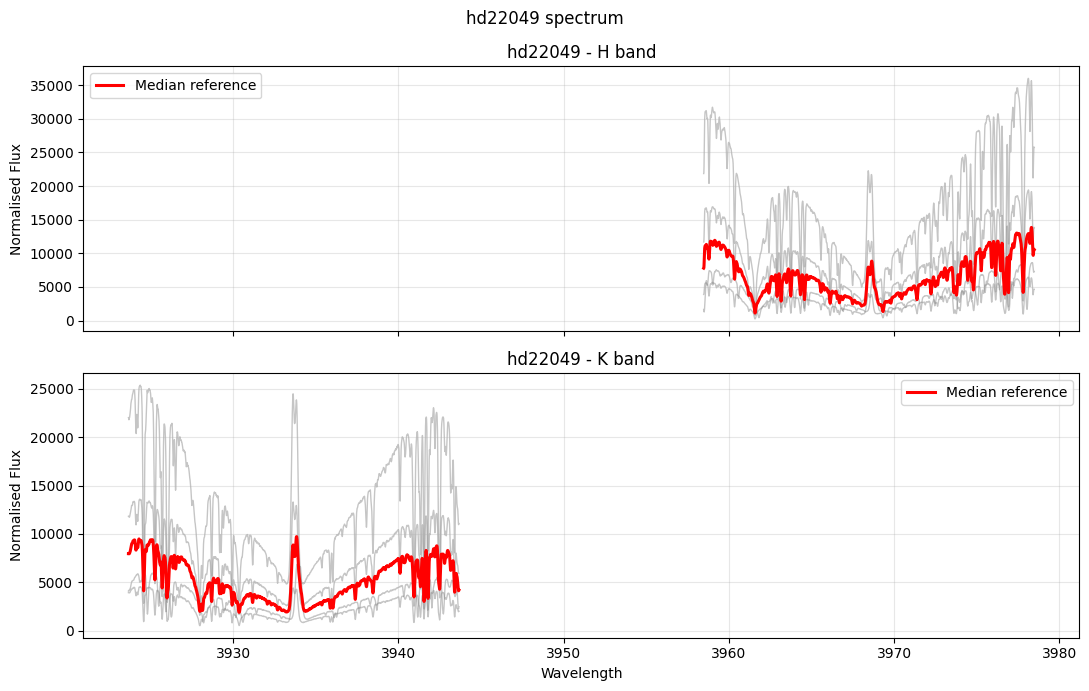

Loaded group: /home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/hd22049
Rows in metadata: 4


In [7]:
plot_star_spectrum('hd22049')